# Assignment 5 - Stock Market Prediction
**DISCLAIMER: THIS IS NOT FINANCIAL ADVICE AND I AM NOT RESPONSIBLE FOR ANY MONEY YOU LOSE IN THE STOCK MARKET**.

In this assignment, you will implement an RNN from scratch to predict future stock prices. We will train our model on market data for the S&P 500 index, from the year 2000 until September 2025. Then, you will use your model to predict the S&P 500 price for the month of September 2025.

You may **NOT** use `torch.nn.LSTM`, `torch.nn.LSTMCell` `torch.nn.GRU`, `torch.nn.GRUCell`, `torch.nn.RNN`, or `torch.nn.RNNCell`.

- (20 points) Implement an Elman RNN
- (20 points) Implement your scan function
- (10 points) Implement a training loop that also computes test loss
- (20 points) Achieve a test loss of 0.05 or lower, and plot your results

- (20 points) Create your own custom RNN
- (10 points) Train and compute the test loss of your custom RNN, achieve a lower loss with your custom RNN than with the Elman RNN

- Extra credit (10 bonus points) complete the assignment using `jax` and `equinox` instead of `torch`. You may still use the `torch` dataloader, but the model should be in `equinox`.

/tmp/ipython-input-1940694757.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_train_dataset = yf.download('^GSPC', start=train_start, end=train_end) # S&P 500
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1940694757.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_test_dataset = yf.download('^GSPC', start=test_start, end=test_end)
[*********************100%***********************]  1 of 1 completed


Price             Close         High          Low         Open
Ticker            ^GSPC        ^GSPC        ^GSPC        ^GSPC
Date                                                          
2010-01-04  1132.989990  1133.869995  1116.560059  1116.560059
2010-01-05  1136.520020  1136.630005  1129.660034  1132.660034
2010-01-06  1137.140015  1139.189941  1133.949951  1135.709961
2010-01-07  1141.689941  1142.459961  1131.319946  1136.270020
2010-01-08  1144.979980  1145.390015  1136.219971  1140.520020


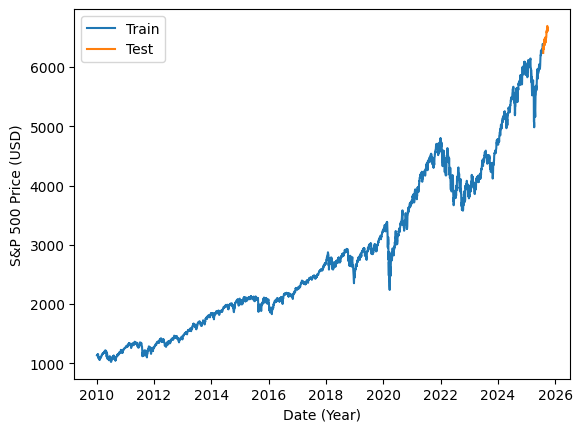

n: 3917


In [ ]:
# Download a stock dataset

import pandas as pd
import numpy as np
import torch
from torch import nn
import yfinance as yf
import matplotlib.pyplot as plt
from typing import Tuple
import copy

torch.manual_seed(0)

T = 40 # The length of each training sequence (also the length of the test set)

train_start = '2010-01-01'
train_end = '2025-08-01'
stock_train_dataset = yf.download('^GSPC', start=train_start, end=train_end) # S&P 500
# Drop volume as the scale can throw off the nn
stock_train_dataset.pop('Volume')
stock_train_dataset.head()

test_start = '2025-08-01' # After train dataset
test_end = '2025-9-30' # Exactly 40 trading days in the test set

stock_test_dataset = yf.download('^GSPC', start=test_start, end=test_end)
stock_test_dataset.pop('Volume')
print(stock_train_dataset.head())


# Now make the dataset nice for our neural network
# We shift the xs and ys by one timestep. The x is today's price and associated data,
# and the y is tomorrow's price.
xs_train = torch.from_numpy(stock_train_dataset.values[:-1].astype(np.float32))
ys_train = torch.from_numpy(stock_train_dataset['Close'].values[1:].astype(np.float32)).reshape(-1, 1)

xs_test = torch.from_numpy(stock_test_dataset.values[:-1].astype(np.float32))
ys_test = torch.from_numpy(stock_test_dataset['Close'].values[1:].astype(np.float32)).reshape(-1, 1)

assert ys_test.shape == (T,1)


plt.plot(stock_train_dataset['Close'])
plt.plot(stock_test_dataset['Close'])
plt.ylabel("S&P 500 Price (USD)")
plt.xlabel("Date (Year)")
plt.legend(["Train", "Test"])
plt.show()
print("n:", xs_train.shape[0])

def rescale_seq(x):
  # Rescale data for faster learning
  assert x.ndim == 2
  x_std, x_mean = torch.std_mean(x, dim=0)
  x = (x - x_mean) / x_std
  return x, {"std": x_std, "mean": x_mean}

def unscale_seq(x, params):
  return x * params["std"] + params["mean"]

# Set up a dataloader to provide full sequences
class TimeSeriesDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        self.seq_len = T

    def __len__(self):
        return self.X.__len__() - (self.seq_len-1)

    def __getitem__(self, index):
       x, x_params = rescale_seq(self.X[index:index+self.seq_len])
       y, y_params = rescale_seq(self.y[index:index+self.seq_len])
       return x, y, {"x": x_params, "y": y_params}

train_dataset = TimeSeriesDataset(xs_train, ys_train)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = 8, shuffle = True)

(20 points)

Now, you will need to implement an Elman RNN. Make sure you look at the type hints to help you understand what each function should take as input, and what it should return as output.

Note that we do not use `forward`! If you implement `forward`, you will lose points. Instead, we implement two functions: `f` and `g`. We will scan `f` to create recurrent states, and then execute `g` on the recurrent states to create outputs.

In [ ]:
# Define some types to help understand the code
RecurrentState = torch.tensor
RecurrentStates = torch.Tensor
Input = torch.Tensor
Inputs = torch.Tensor
Output = torch.Tensor
Outputs = torch.Tensor

torch.manual_seed(0)

class ElmanRNN(nn.Module):
    def __init__(self, d_x: int, d_h: int, d_y: int):
      super().__init__()
      raise NotImplementedError("TODO: Create your RNN parameters")

    def f(self, h: RecurrentState, x: Input) -> RecurrentState:
      raise NotImplementedError("TODO: Implement your recurrent update")
      return h

    def g(self, h: RecurrentStates) -> Outputs:
      # raise NotImplementedError("TODO: Implement your output function")
      return self.output(h)

    def initial_recurrent_state(self) -> RecurrentState:
      """Return the initial recurrent state (at timestep 0)"""
      #raise NotImplementedError("TODO: Return an initial recurrent state")
      return torch.zeros((d_h,))

d_x = NotImplementedError("TODO: Implement d_x")
d_h = NotImplementedError("TODO: Implement d_h")
d_y = NotImplementedError("TODO: Implement d_z")


# Check to make sure your RNN works
rnn = ElmanRNN(d_x, d_h, d_y)
# No forward allowed
try:
  rnn.forward()
  assert False, "You should not implement the forward function"
except NotImplementedError:
  no_forward = True

h_0 = rnn.initial_recurrent_state() # Initial recurrent state
x_1 = xs_train[0]
h_1 = rnn.f(h_0, x_1)
assert h_1.shape == h_0.shape, "Your recurrent states have different shapes"
y_1 = rnn.g(h_1)
assert y_1.shape == (d_y,), "Your output has the wrong shape"
assert torch.linalg.norm(h_0 - h_1) > 0.001, "Your recurrent state was not updated"

Next, implement your `scan` function. Your `scan` function should take an initial recurrent state and a tensor of inputs. It should return a tensor of corresponding recurrent states.

In [ ]:
def scan(f: nn.Module, h: RecurrentState, xs: Inputs) -> RecurrentStates:
  """scan(f): H x X^T |-> H^T """
  raise NotImplementedError("TODO: Implement the scan function")

# Test your scan
h_0 = rnn.initial_recurrent_state() # Initial recurrent state
xs = xs_train[:5]

hs = scan(rnn.f, h_0, xs)
assert hs.shape == (5, d_h), "Your scan function returns the wrong shape"
ys = rnn.g(hs)

(10 points)

Now, implement your training loop. Remember that you are training over **sequences** instead of single inputs. You should use the following functions `rnn.f, rnn.g, scan`. You should compute recurrent states and $y$ predictions. Finally, you should compute the loss and update the parameters using the optimizer. To be clear, during training both your input and prediction tensors should be shape $B \times T$.

After you are done training, compute the loss over $T$ outputs from the **test set** `xs_test, ys_test`. Note the test set does not have a batch dimension.

You should also return the vector of predictions `ys_test_preds` for plotting:

$\begin{bmatrix}g(f(x_{1}, h_0))\\g(f(x_{2}, h_1))\\ \vdots\\ g(f(x_{T}, h_{T-1}))\end{bmatrix}$

In [ ]:
def train_one_epoch(rnn: nn.Module, optimizer: torch.optim.Optimizer) -> Tuple[torch.Tensor, torch.Tensor]:
  """Implement your train loop here.

  The train loop should take in an RNN and train the RNN using the train_loader.

  You should only train for one epoch (one pass through the dataset)

  This function should return:
    1. The test loss at the end of the epoch
    2. The predictions of the RNN on the test set (shape T x d_y)

  HINT: You might want to use vmap to handle the batch dimension for scan:
  hs = torch.vmap(scan, in_dims=(None, None, 0))(rnn.f, rnn.initial_recurrent_state(), xs)
  """
  for i, sequence in enumerate(train_loader):
    xs, ys, norm_params = sequence # B x T x F
    raise NotImplementedError("Implement training loop")

  test_input = rescale_seq(xs_test)[0]
  test_output = rescale_seq(ys_test)[0]
  raise NotImplementedError("Compute test loss")

  return test_loss, ys_test_preds

(20 points) Now, train your model and plot the results. You should not need to write any code in the folowing two cells. You should achieve a test loss of 0.15 or lower.

In [ ]:
# Use the function below to plot your results

def plot_test_results(y_preds: torch.Tensor) -> None:
  """Given T predictions, plot the predicted stock price from 1 ... T
  and compare it to the true stock price y_1 ... y_T"""
  # Preds are rescaled but flat is not, undo pred
  # norm using dataset params
  _, params = rescale_seq(ys_test)
  flat_preds = unscale_seq(y_preds, params).flatten().detach()
  flat_y = ys_test.flatten()

  t_offset = list(range(len(ys_train), len(ys_train) + T))
  plt.plot(2010 + np.array(range(len(ys_train))) / 365, ys_train)
  plt.plot(2010 + np.array(t_offset) / 365, flat_preds, color='green', alpha=0.5)
  plt.plot(2010 + np.array(t_offset) / 365, flat_y, color='red', alpha=0.5)
  plt.legend(["History", "Prediction", "True"])
  plt.xlabel("Date")
  plt.ylabel("S&P Price (1000 USD)")
  plt.show()

  plt.plot(flat_preds)
  plt.plot(flat_y)
  plt.legend(["Prediction", "True"])
  plt.xlabel("Days into the Future")
  plt.ylabel("S&P Price (1000 USD)")
  plt.show()

In [ ]:
# Put it all together. Train the network, print the losses, and plot the results.
torch.manual_seed(0)
rnn = ElmanRNN(d_x, d_h, d_y)
optimizer = torch.optim.AdamW(rnn.parameters(), lr=0.00001)
for epoch in range(5):
  test_loss, predicted_y = train_one_epoch(rnn, optimizer)
plot_test_results(predicted_y)

(20 points)

Great job! You've trained your first RNN, and hopefully it is surprisingly good at predicting stock prices!

Now, let's make the RNN even better. Use whatever methods you wish to improve the RNN. You can play with new activation functions, normalization methods, residual connections, deeper layers, different initialization, etc. You can even change the structure of your RNN, add forgetting, or use multiple recurrent states. You might want to search for some papers and see what other researchers do to improve their neural networks.

In [ ]:
class MyRNN(nn.Module):
  def __init__(self, d_x: int, d_h: int, d_y: int):
    super().__init__()
    raise NotImplementedError("TODO: Create your RNN parameters")

  def f(self, h: RecurrentState, x: Input) -> RecurrentState:
    raise NotImplementedError("TODO: Implement your recurrent update")

  def g(self, h: RecurrentStates) -> Output:
    raise NotImplementedError("TODO: Implement your output function")

  def initial_recurrent_state(self) -> RecurrentState:
    """Return the initial recurrent state (at timestep 0)"""
    raise NotImplementedError("TODO: Return an initial recurrent state")

(10 points)

Run your custom RNN and plot the results. See if you can achieve a lower test loss than the Elman RNN

In [ ]:
# Put it all together. Train the network, print the losses, and plot the results.
torch.manual_seed(0)
rnn = MyRNN(d_x, d_h, d_y)
optimizer = torch.optim.AdamW(rnn.parameters(), lr=0.00001)
for epoch in range(5):
  test_loss, predicted_y = train_one_epoch(rnn, optimizer)
plot_test_results(predicted_y)